In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()


Saving S&P500_Financials.xlsx to S&P500_Financials.xlsx


,symbol,quarter,revenue(in billions),grossProfit(in billions),operatingIncome(in billions),netIncome(in billions),eps,ebitda(in billions),totalAssets(in billions),totalLiabilities(in billions),...,totalStockholdersEquity(in billions),netCashProvidedByOperatingActivities(in billions),netCashUsedForInvestingActivites(in billions),netCashUsedProvidedByFinancingActivities(in billions),freeCashFlow(in billions),GDP_Growth,Inflation,Interest_Rate,Unemployment_Rate,SP500_Growth
0,AAPL,2004-03-27,19.09,5.30,0.52,0.46,0.0022,0.98,67.35,22.45,...,44.90,0.61,-4.03,-2.24,0.26,NaN,NaN,NaN,NaN,NaN
1,AAPL,2004-06-26,20.14,5.59,0.72,0.61,0.0029,1.21,72.23,24.11,...,48.12,2.11,-4.60,2.11,1.73,NaN,NaN,NaN,NaN,NaN
2,AAPL,2004-09-25,23.50,6.34,1.28,1.06,0.0049,1.87,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
3,AAPL,2004-09-30,0.00,0.00,0.00,0.00,NaN,0.00,80.50,29.74,...,50.76,4.43,-7.02,1.08,3.84,0.948594,0.637733,4.303333,5.433333,NaN
4,AAPL,2004-12-25,34.90,9.96,4.03,2.95,0.0134,4.44,93.62,35.72,...,57.90,7.75,-15.23,2.54,7.17,NaN,NaN,NaN,NaN,NaN


In [ ]:
!pip install qiskit-machine-learning qiskit-algorithms --quiet



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Statevector


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Statevector


In [ ]:
# Basic symbol → sector mapping (extend if you have more tickers)
sector_map = {
    # Information Technology
    "AAPL": "Information Technology",
    "MSFT": "Information Technology",
    "NVDA": "Information Technology",
    "AVGO": "Information Technology",
    "ADBE": "Information Technology",

    # Communication Services
    "GOOGL": "Communication Services",
    "GOOG": "Communication Services",
    "META": "Communication Services",
    "NFLX": "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",
    "HD": "Consumer Discretionary",
    "MCD": "Consumer Discretionary",

    # Financials
    "JPM": "Financials",
    "BAC": "Financials",
    "BRK.B": "Financials",
    "BRK.A": "Financials",
    "V": "Financials",
    "MA": "Financials",
    "WFC": "Financials",

    # Health Care
    "UNH": "Health Care",
    "LLY": "Health Care",
    "JNJ": "Health Care",
    "ABBV": "Health Care",
    "PFE": "Health Care",

    # Consumer Staples
    "PG": "Consumer Staples",
    "KO": "Consumer Staples",
    "PEP": "Consumer Staples",
    "COST": "Consumer Staples",
    "WMT": "Consumer Staples",

    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",

    # Industrials (examples)
    "BA": "Industrials",
    "CAT": "Industrials",
    "GE": "Industrials",
}

# Ensure we have a symbol column
if "symbol" not in df.columns:
    raise ValueError("Expected a 'symbol' column in the dataset.")

# Create Sector column
df["Sector"] = df["symbol"].map(sector_map).fillna("Other")

print(df[["symbol", "Sector"]].drop_duplicates().head(20))
print("Unique sectors:", df["Sector"].unique())


     symbol                  Sector
0      AAPL  Information Technology
100    AMZN  Consumer Discretionary
184    AVGO  Information Technology
250   BRK-B                   Other
334    GOOG  Communication Services
418   GOOGL  Communication Services
502     JNJ             Health Care
586     JPM              Financials
670     LLY             Health Care
754      MA              Financials
838    META  Communication Services
894    MSFT  Information Technology
978    NFLX  Communication Services
1062   NVDA  Information Technology
1146   ORCL                   Other
1230   PLTR                   Other
1254   TSLA  Consumer Discretionary
1322      V              Financials
1397    WMT        Consumer Staples
1481    XOM                  Energy
Unique sectors: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Consumer Staples'
 'Energy']


In [ ]:
TARGET_COL = "freeCashFlow(in billions)"
TIME_COL   = "quarter"   # change if your time column has a different name
ID_COL     = "symbol"
SECTOR_COL = "Sector"    # we just created this

feature_cols = [
    "netCashProvidedByOperatingActivities(in billions)",  # micro 1
    "netCashUsedForInvestingActivites(in billions)",      # micro 2
    "cashAndCashEquivalents(in billions)",                # micro 3
    "revenue(in billions)",                               # micro 4
    "operatingIncome(in billions)",                       # micro 5
    "totalLiabilities(in billions)",                      # micro 6
    "totalAssets(in billions)",                           # micro 7
    "GDP_Growth",                                         # macro 1
    "Interest_Rate",                                      # macro 2
    "SP500_Growth",                                       # macro 3
]

# Keep only rows where everything needed is present
cols_needed = [TARGET_COL, SECTOR_COL] + feature_cols
df_q = df.dropna(subset=cols_needed).copy()

print("After cleaning, shape:", df_q.shape)
print("Sectors in cleaned data:", df_q[SECTOR_COL].unique())


After cleaning, shape: (519, 22)
Sectors in cleaned data: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']


In [ ]:
def quantum_feature_map(x):
    """
    Encode a classical vector x into a quantum state using Ry rotations.
    Number of qubits = len(x).
    """
    n = len(x)
    qc = QuantumCircuit(n)
    for i, val in enumerate(x):
        qc.ry(val, i)
    return qc

def quantum_kernel_matrix(X1, X2):
    """
    Build quantum kernel matrix K where
    K_ij = |<psi(x_i) | psi(x_j)>|^2
    using exact statevectors.
    """
    K = np.zeros((len(X1), len(X2)))

    sv1 = [Statevector.from_instruction(quantum_feature_map(x)) for x in X1]
    sv2 = [Statevector.from_instruction(quantum_feature_map(x)) for x in X2]

    for i, psi in enumerate(sv1):
        for j, phi in enumerate(sv2):
            K[i, j] = abs(psi.inner(phi))**2

    return K


Sectors found in QSVM dataset: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']

=== Sector: Information Technology (49 rows) ===
  Computing quantum kernel matrices...
  MAE:  59.7236
  R²:   -0.3191


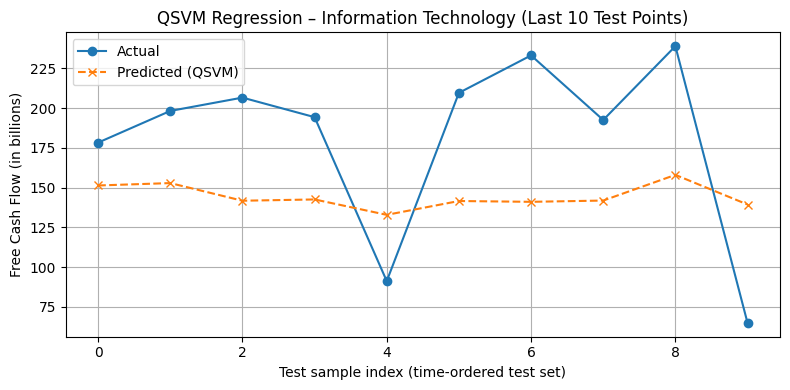


=== Sector: Consumer Discretionary (72 rows) ===
  Computing quantum kernel matrices...
  MAE:  54.6617
  R²:   -0.1395


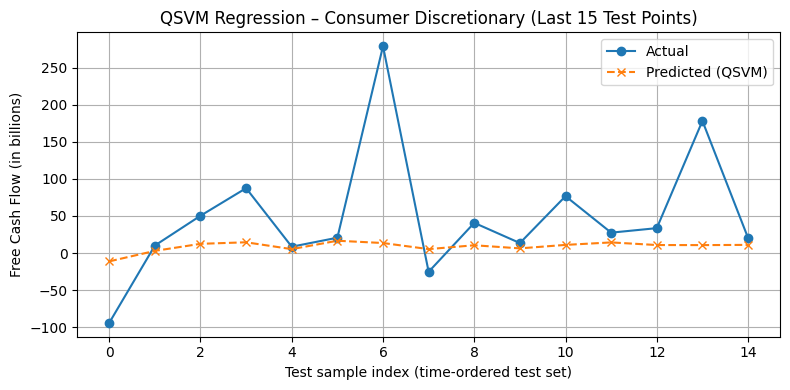


=== Sector: Other (60 rows) ===
  Computing quantum kernel matrices...
  MAE:  22.7179
  R²:   0.4678


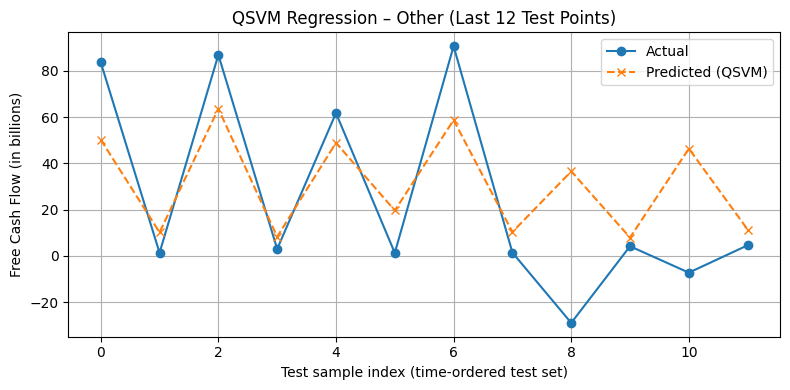


=== Sector: Communication Services (144 rows) ===
  Computing quantum kernel matrices...
  MAE:  59.6889
  R²:   0.0675


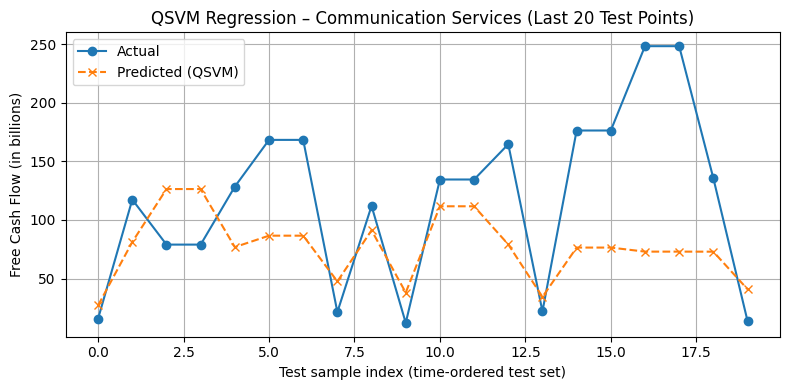


=== Sector: Health Care (50 rows) ===
  Computing quantum kernel matrices...
  MAE:  19.6379
  R²:   0.3856


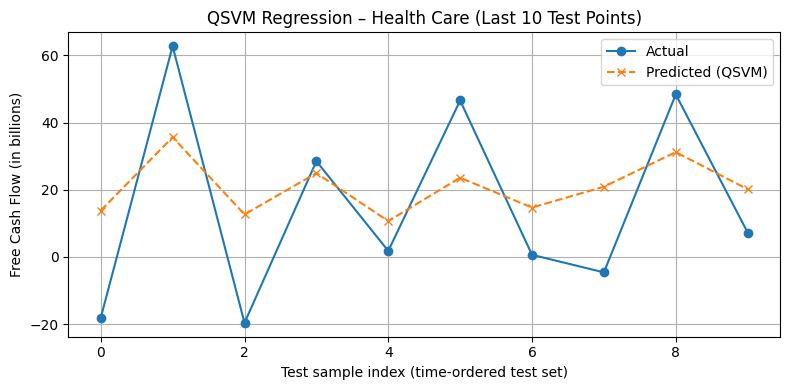


=== Sector: Financials (108 rows) ===
  Computing quantum kernel matrices...
  MAE:  295.0430
  R²:   0.0066


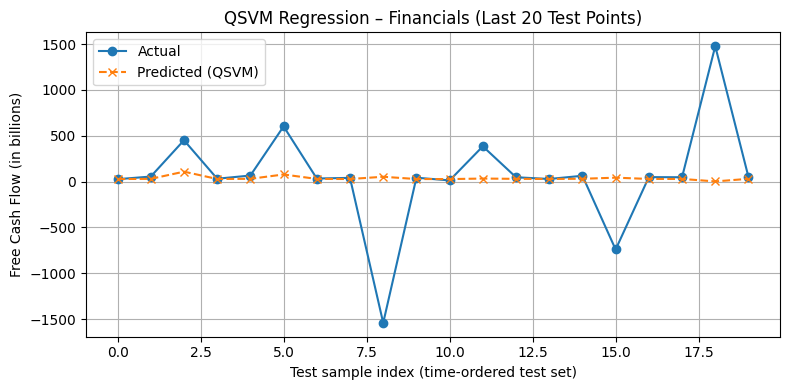


=== Sector: Energy (36 rows) ===
  Computing quantum kernel matrices...
  MAE:  26.1386
  R²:   -0.3047


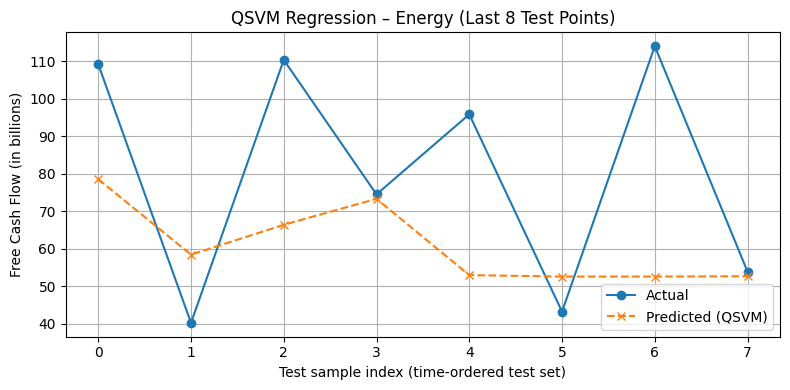

In [ ]:
results = []
PLOT_PER_SECTOR = True   # Set to False if you don’t want graphs for every sector

sectors = df_q[SECTOR_COL].dropna().unique()
print("Sectors found in QSVM dataset:", sectors)

for sec in sectors:
    sub = df_q[df_q[SECTOR_COL] == sec].copy()
    n_rows = len(sub)

    print(f"\n=== Sector: {sec} ({n_rows} rows) ===")

    # Need a minimum number of points for time split + training
    if n_rows < 25:
        print(f"  Skipping {sec}: too few rows.")
        continue

    # Sort by time if available
    if TIME_COL in sub.columns:
        sub = sub.sort_values(TIME_COL)

    # Build X and y
    X = sub[feature_cols].values
    y = sub[TARGET_COL].values

    # Scale features and target within the sector
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaled = X_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

    # 80/20 train–test split (time-based)
    split_idx = int(0.8 * len(X_scaled))
    if split_idx == 0 or split_idx == len(X_scaled):
        print(f"  Skipping {sec}: cannot split into train/test.")
        continue

    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

    # Compute quantum kernel matrices
    print("  Computing quantum kernel matrices...")
    K_train = quantum_kernel_matrix(X_train, X_train)
    K_test  = quantum_kernel_matrix(X_test,  X_train)

    # QSVM regression via SVR with precomputed quantum kernel
    svr = SVR(kernel="precomputed")
    svr.fit(K_train, y_train)

    # Predict on test kernel
    y_pred_scaled = svr.predict(K_test)

    # Back-transform to original cash-flow units
    y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    mae  = mean_absolute_error(y_test_real, y_pred_real)
    #rmse = mean_squared_error(y_test_real, y_pred_real, squared=False)
    r2   = r2_score(y_test_real, y_pred_real)

    print(f"  MAE:  {mae:,.4f}")
    #print(f"  RMSE: {rmse:,.4f}")
    print(f"  R²:   {r2:.4f}")

    results.append({
        "Sector": sec,
        "n_obs": n_rows,
        "MAE": mae,
        #"RMSE": rmse,
        "R2": r2,
    })

    # Optional: last 20 test points plot
    if PLOT_PER_SECTOR:
        N = min(20, len(y_test_real))
        plt.figure(figsize=(8, 4))
        plt.plot(y_test_real[-N:], label="Actual", marker="o")
        plt.plot(y_pred_real[-N:], label="Predicted (QSVM)", marker="x", linestyle="--")
        plt.title(f"QSVM Regression – {sec} (Last {N} Test Points)")
        plt.xlabel("Test sample index (time-ordered test set)")
        plt.ylabel("Free Cash Flow (in billions)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
results_df = pd.DataFrame(results).sort_values("Sector")
results_df


,Sector,n_obs,MAE,R2
3,Communication Services,144,59.688885,0.067462
1,Consumer Discretionary,72,54.661725,-0.139504
6,Energy,36,26.138615,-0.304704
5,Financials,108,295.042985,0.006639
4,Health Care,50,19.637871,0.385552
0,Information Technology,49,59.723607,-0.319051
2,Other,60,22.717875,0.467763


In [ ]:
results_df.to_csv("QSVM_Sectorwise_Results.csv", index=False)

from google.colab import files
files.download("QSVM_Sectorwise_Results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>